# Exploratory Data Analysis

This notebook presents an exploratory data analysis (EDA) of the MVTec Anomaly Detection [(MVTec AD)](https://www.mvtec.com/research-teaching/datasets/mvtec-ad) dataset. MVTec AD is a benchmark dataset for unsupervised anomaly detection in industrial inspection and contains over 5,000 images across 15 object categories. Each category contains defect-free training images and a test set consisting of both normal and anomalous samples.

The purpose of this analysis is to:

1. Identify the object and texture categories present within the dataset.
2. Examine the distribution of normal and anomalous samples.
3. Investigate the defect types available within each category.
4. Analyse image characteristics such as resolution, brightness, sharpness, and contrast.
5. Identify potential challenges and limitations that may influence anomaly detection performance.
6. Inform preprocessing and model design decisions for the subsequent stages of the project.

In [2]:
import os 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb

import numpy as np

import cv2

from pathlib import Path

ROOT = Path.cwd().parents[1]

IMAGE_DIR = ROOT / "images/EDA"
CACHE_DIR = ROOT / "data/cache"
RESULTS_DIR = ROOT / "data/results/data_analysis"

In [3]:
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_csv(ROOT / "data/metadata.csv")

## 1. Identify the object and texture categories present within the dataset.

In [4]:
categories = sorted(df["category"].unique())

print(len(categories))
categories

15


['bottle',
 'cable',
 'capsule',
 'carpet',
 'grid',
 'hazelnut',
 'leather',
 'metal_nut',
 'pill',
 'screw',
 'tile',
 'toothbrush',
 'transistor',
 'wood',
 'zipper']

## 2. Examine the distribution of normal and anomalous samples.

This section examines how samples are distributed across the dataset. Understanding the balance between normal and anomalous images helps inform about any class imbalances may influence anomaly detection performance and evaluation metrics.

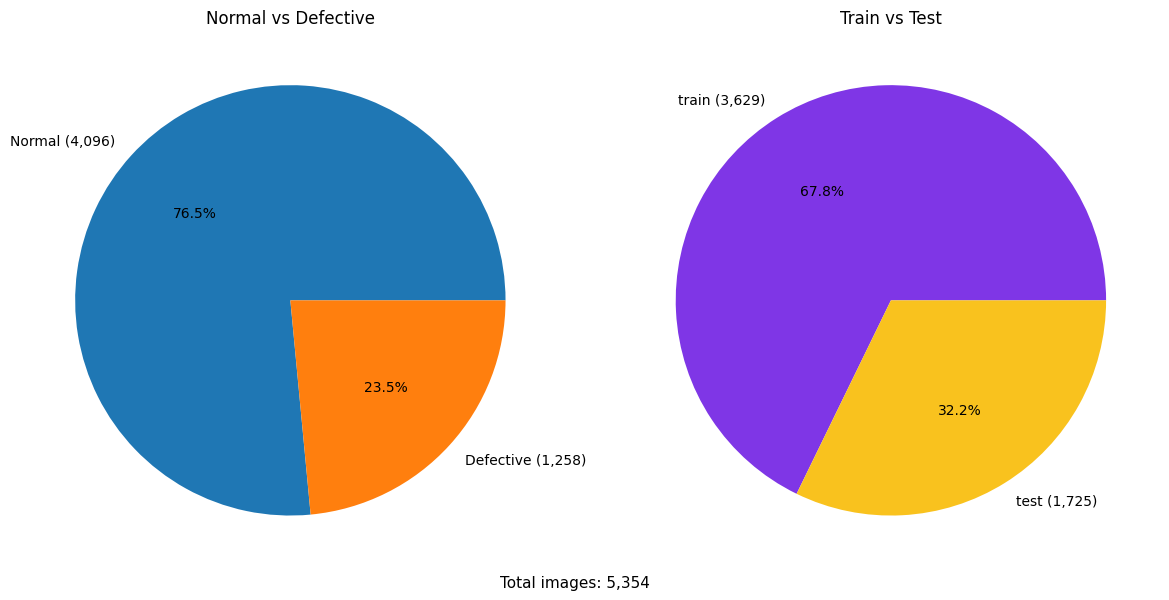

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

defect_counts = (df["label"].map({0: "Normal", 1: "Defective"}).value_counts())
labels = [f"{label} ({count:,})" for label, count in defect_counts.items()]

defect_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=labels,
    ax=axes[0],
)

split_counts = df["split"].value_counts()
labels = [f"{label} ({count:,})" for label, count in split_counts.items()]

split_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=labels,
    ax=axes[1],
    colors=("#7F36E6", "#F9C21E")
)

axes[0].set_title("Normal vs Defective")

axes[1].set_title("Train vs Test")

fig.text(
    0.5, 0.02,
    f"Total images: {len(df):,}",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/class_distribution_pie.svg', bbox_inches="tight", pad_inches=0.1)
plt.show()

### Category Distribution

This investigates how images are distributed across the 15 MVTec categories. Identifying category-level imbalances helps determine whether certain categories may be overrepresented during evaluation.

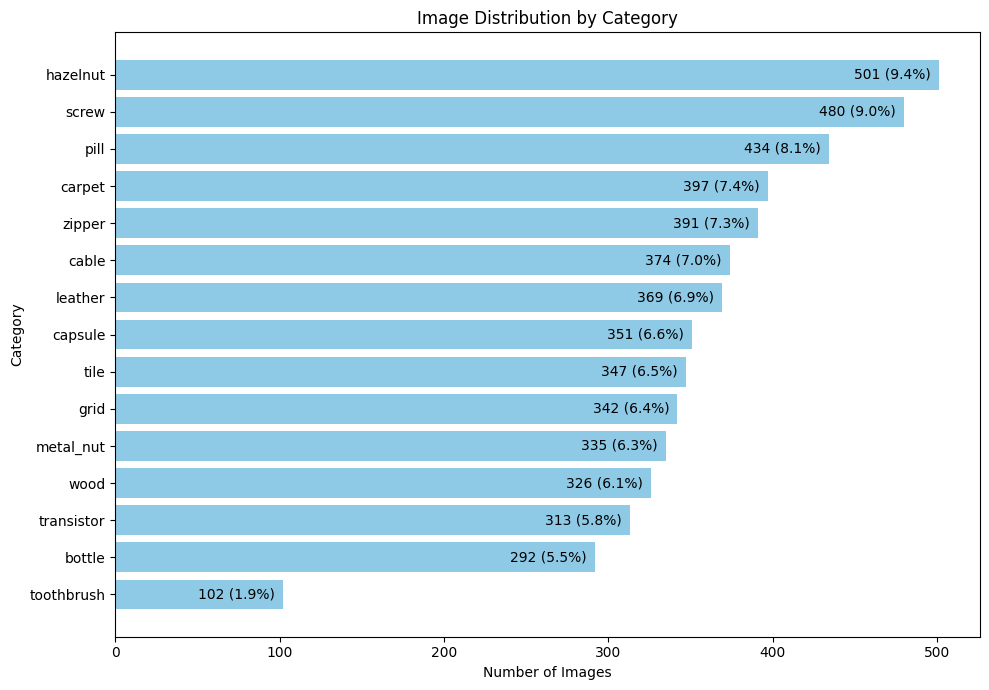

In [6]:
category_counts = df["category"].value_counts().sort_values()
total = category_counts.sum()

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    category_counts.index,
    category_counts.values,
    color="#8ecae6"
)

for bar, count in zip(bars, category_counts.values):
    ax.text(
        bar.get_width() - 5,                 # slightly inside right edge
        bar.get_y() + bar.get_height() / 2, # vertically centred
        f"{count} ({count / total:.1%})",
        ha="right",
        va="center"
    )

ax.set_xlabel("Number of Images")
ax.set_ylabel("Category")
ax.set_title("Image Distribution by Category")

fig.tight_layout()

fig.savefig(
    f"{IMAGE_DIR}/category_distribution_bar.svg",
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()

The dataset is reasonably balanced across categories, although some categories contain more images than others. No category dominates the dataset to a degree that would significantly bias overall evaluation.

#

This figure shows the proportion of normal and defective samples within each category. As MVTec is designed for anomaly detection, categories may contain different ratios of normal and anomalous images depending on the number of defect types available.

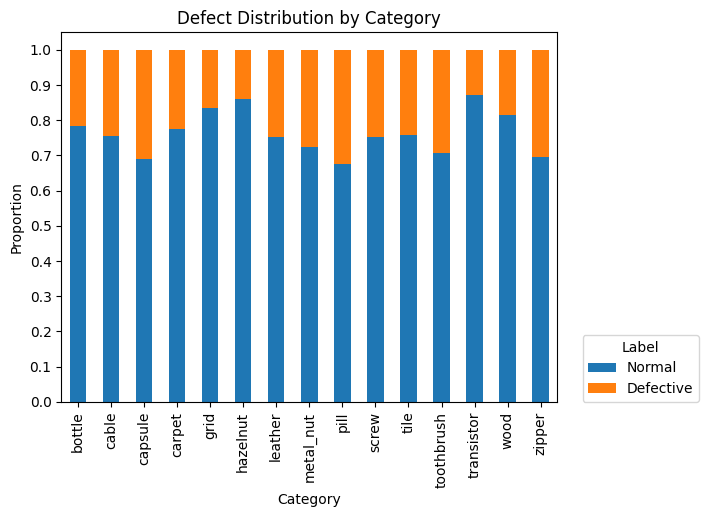

In [7]:
ax = (df.groupby("category")["label"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True))

ax.legend(title="Label", labels=["Normal", "Defective"], bbox_to_anchor=(1.3, 0.2), loc="upper right")

plt.title("Defect Distribution by Category")

plt.xlabel("Category")

plt.ylabel("Proportion")
plt.yticks(np.arange(0, 1.1, 0.1))

plt.savefig(f'{IMAGE_DIR}/defect_distribution_category_chart.svg', bbox_inches="tight", pad_inches=0.1)
plt.show()

The proportion of defective samples varies between categories. Categories containing a larger number of defect types generally show a higher proportion of anomalous test samples.

## 3. Investigate the defect types available within each category.

Understanding the variety of defect types present within each category is for assessing dataset complexity. Categories containing a larger number of defect types may present a more challenging anomaly detection task.

The following visualisations show how defect types are distributed within each category's test set. This provides insight into the relative frequency of different anomaly types.

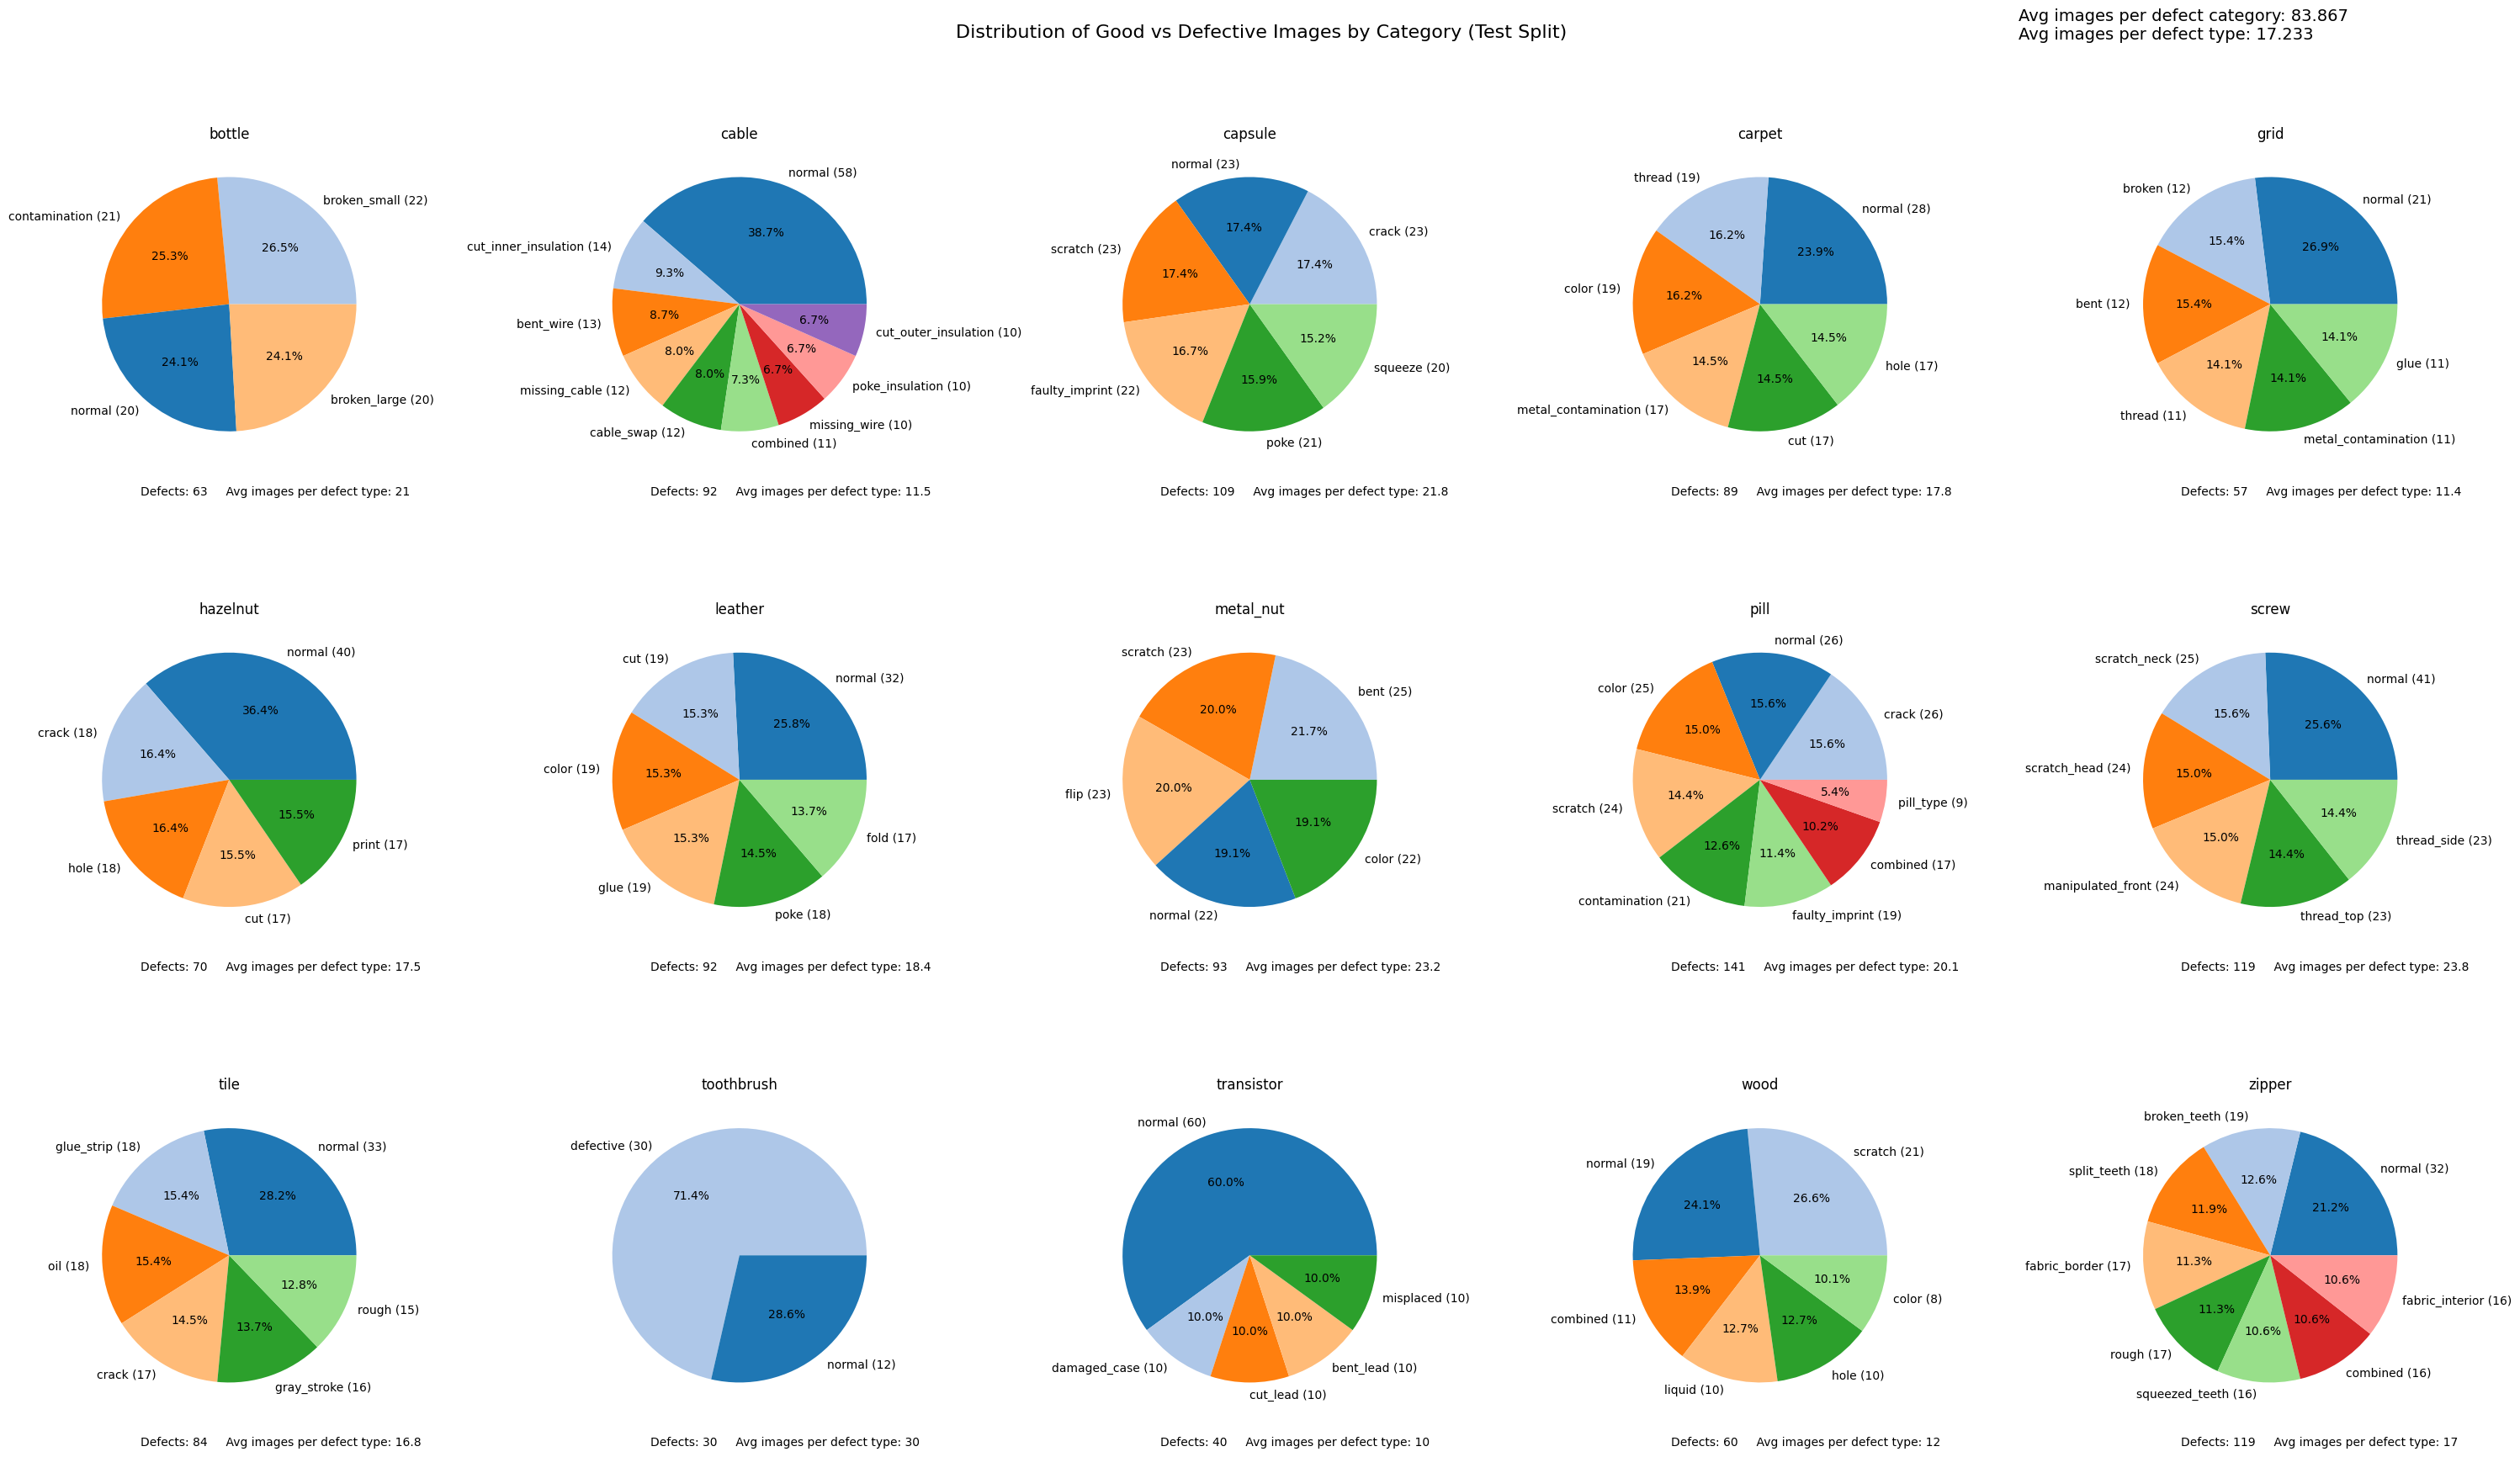

In [8]:
###
# Something I can come back too if embeddings put scratches/contamination in the same cluster together across different 
# categories should probbaly make those defects share colour
###

fig, axes = plt.subplots(3, 5, figsize=(30, 18))

axes = axes.flatten()

fig.suptitle(
    "Distribution of Good vs Defective Images by Category (Test Split)",
    fontsize=16
)

defect_sums = []
defect_types_sum = []
for i, category in enumerate(sorted(df["category"].unique())):
    ax = axes[i]

    counts = (  # How man defects in each category
        df[
            (df["category"] == category)
            & (df["split"] == "test")
        ]["type"]
        .value_counts()
    )

    palette = [
        colour
        for colour in plt.cm.tab20.colors
        if colour != to_rgb("tab:blue")
    ]

    colors = []
    labels = []

    defect_sum = 0
    defect_colour_idx = 0
    for defect_type, count in counts.items():

        if defect_type == "good":
            colors.append("tab:blue")
            labels.append(f"normal ({count})")
        else:
            colors.append(palette[defect_colour_idx])
            defect_colour_idx += 1

            labels.append(f"{defect_type} ({count})")

            defect_sum += count
            defect_types_sum.append(count)

    defect_sums.append(defect_sum)

    
    counts.plot(
        kind="pie",
        ax=ax,
        autopct="%1.1f%%",
        labels=labels,
        colors=colors
    )

    ax.set_title(category)
    ax.text(
        -0.7, -1.5,
        f"Defects: {defect_sum}     "
        f"Avg images per defect type: {defect_sum / (len(counts) - 1):.3g}"
    )

fig.text(
    0.8, 0.97,
    f"Avg images per defect category: {np.mean(defect_sums):.3f}\nAvg images per defect type: {np.mean(defect_types_sum):.3f}",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.97]) # How much of the plot should be used to arrange subplots
plt.savefig(f'{IMAGE_DIR}/distibution_defects_category_pies.svg', bbox_inches="tight", pad_inches=0.1)
plt.show()

The number and distribution of defect types varies substantially between categories. Some categories contain only a small number of anomaly classes, while others contain a wider range of defect variations.

#

This analysis examines the number of unique defect types present within each category. A larger number of defect types may indicate increased anomaly diversity and greater detection complexity.

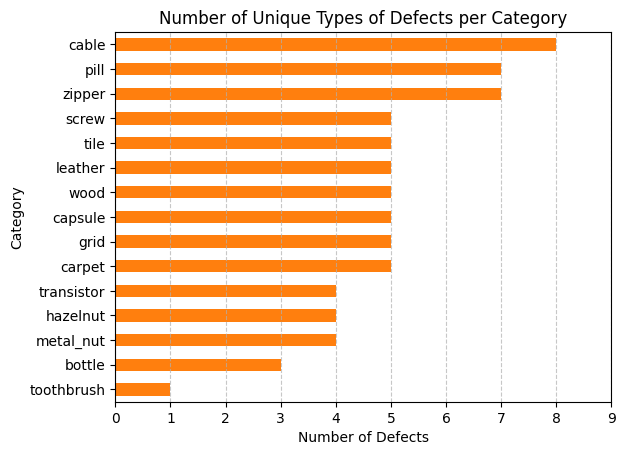

In [9]:
cat_type = (
    df[df["type"] != "good"]
    .groupby("category")["type"]
    .nunique()
)

max_types = cat_type.max() + 1

cat_type.sort_values().plot(kind="barh", color="tab:orange")

plt.title("Number of Unique Types of Defects per Category")

plt.ylabel("Category")

plt.xlabel("Number of Defects")
plt.xticks(range(0, max_types + 1))

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.savefig(f'{IMAGE_DIR}/defects_per_category_chart.svg', bbox_inches="tight", pad_inches=0.1)
plt.show()

In [10]:
defects = df[df["label"] == 1]

defects["defect_coverage"].describe()

count    1258.000000
mean        0.043883
std         0.087412
min         0.000371
25%         0.004943
50%         0.015440
75%         0.038875
max         0.493205
Name: defect_coverage, dtype: float64

In [11]:
coverage_by_category = (
    defects
    .groupby("category")["defect_coverage"]
    .agg(["mean", "median", "std", "min", "max"])
).round(3)

coverage_by_category.to_csv(RESULTS_DIR / "defect_coverage_stats.csv")
coverage_by_category

,mean,median,std,min,max
category,,,,,
bottle,0.076,0.057,0.058,0.006,0.274
cable,0.047,0.037,0.037,0.001,0.226
capsule,0.011,0.004,0.018,0.000,0.081
carpet,0.021,0.015,0.019,0.002,0.080
grid,0.009,0.006,0.008,0.002,0.036
hazelnut,0.034,0.016,0.053,0.002,0.277
leather,0.009,0.005,0.011,0.001,0.069
metal_nut,0.145,0.037,0.196,0.004,0.487
pill,0.040,0.010,0.098,0.001,0.410


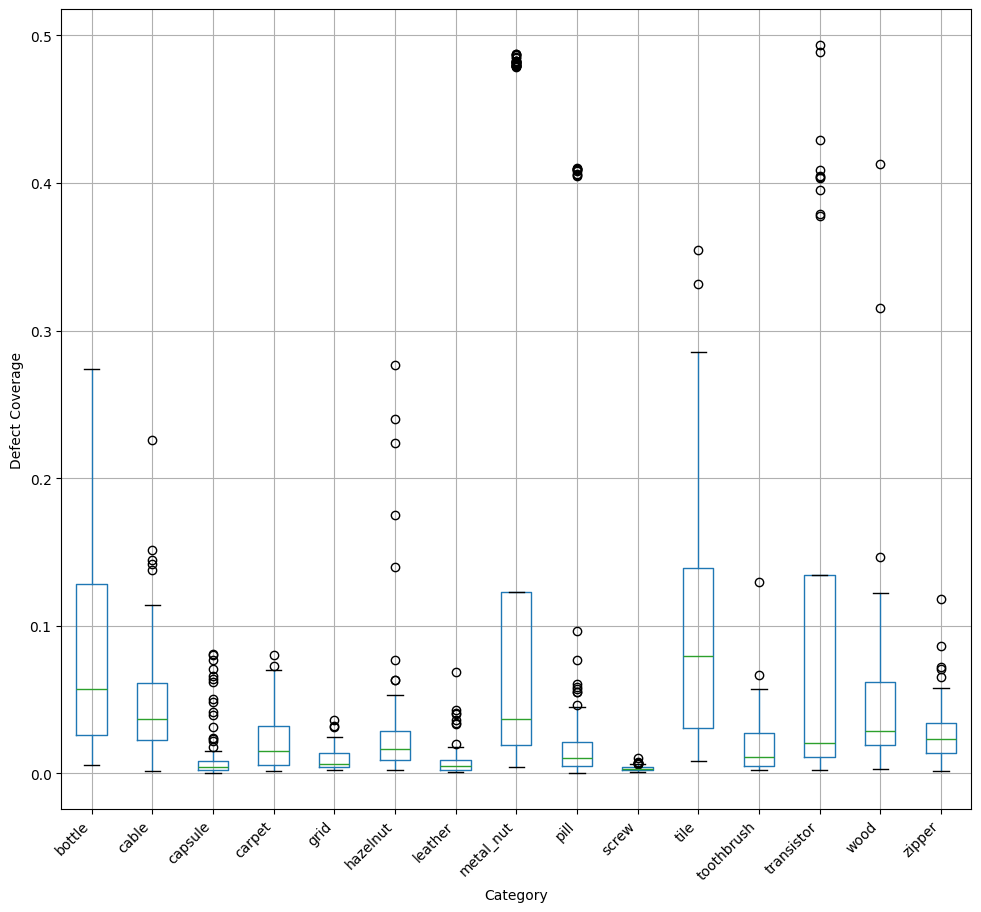

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

defects.boxplot(
    column="defect_coverage",
    by="category",
    rot=45,
    ax=ax
)

fig.suptitle("")
ax.set_title("")

ax.set_ylabel("Defect Coverage")
ax.set_xlabel("Category")

plt.xticks(rotation=45, ha="right")

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.98,
    bottom=0.18,
)

fig.savefig(
    f"{IMAGE_DIR}/defect_coverage_boxplots.svg",
    bbox_inches="tight",
    pad_inches=0.02,
)

In [13]:
defects[defects["category"] == "metal_nut"].groupby("type")["defect_coverage"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
type,,,,
bent,0.020361,0.018729,0.007057,0.046990
color,0.023581,0.020902,0.004357,0.065690
flip,0.482177,0.481727,0.478467,0.487247
scratch,0.058987,0.055365,0.018984,0.123010


The following figure provides representative examples of normal and defective samples for each category. Visual inspection helps identify differences in texture, appearance, and defect characteristics throughout the dataset.

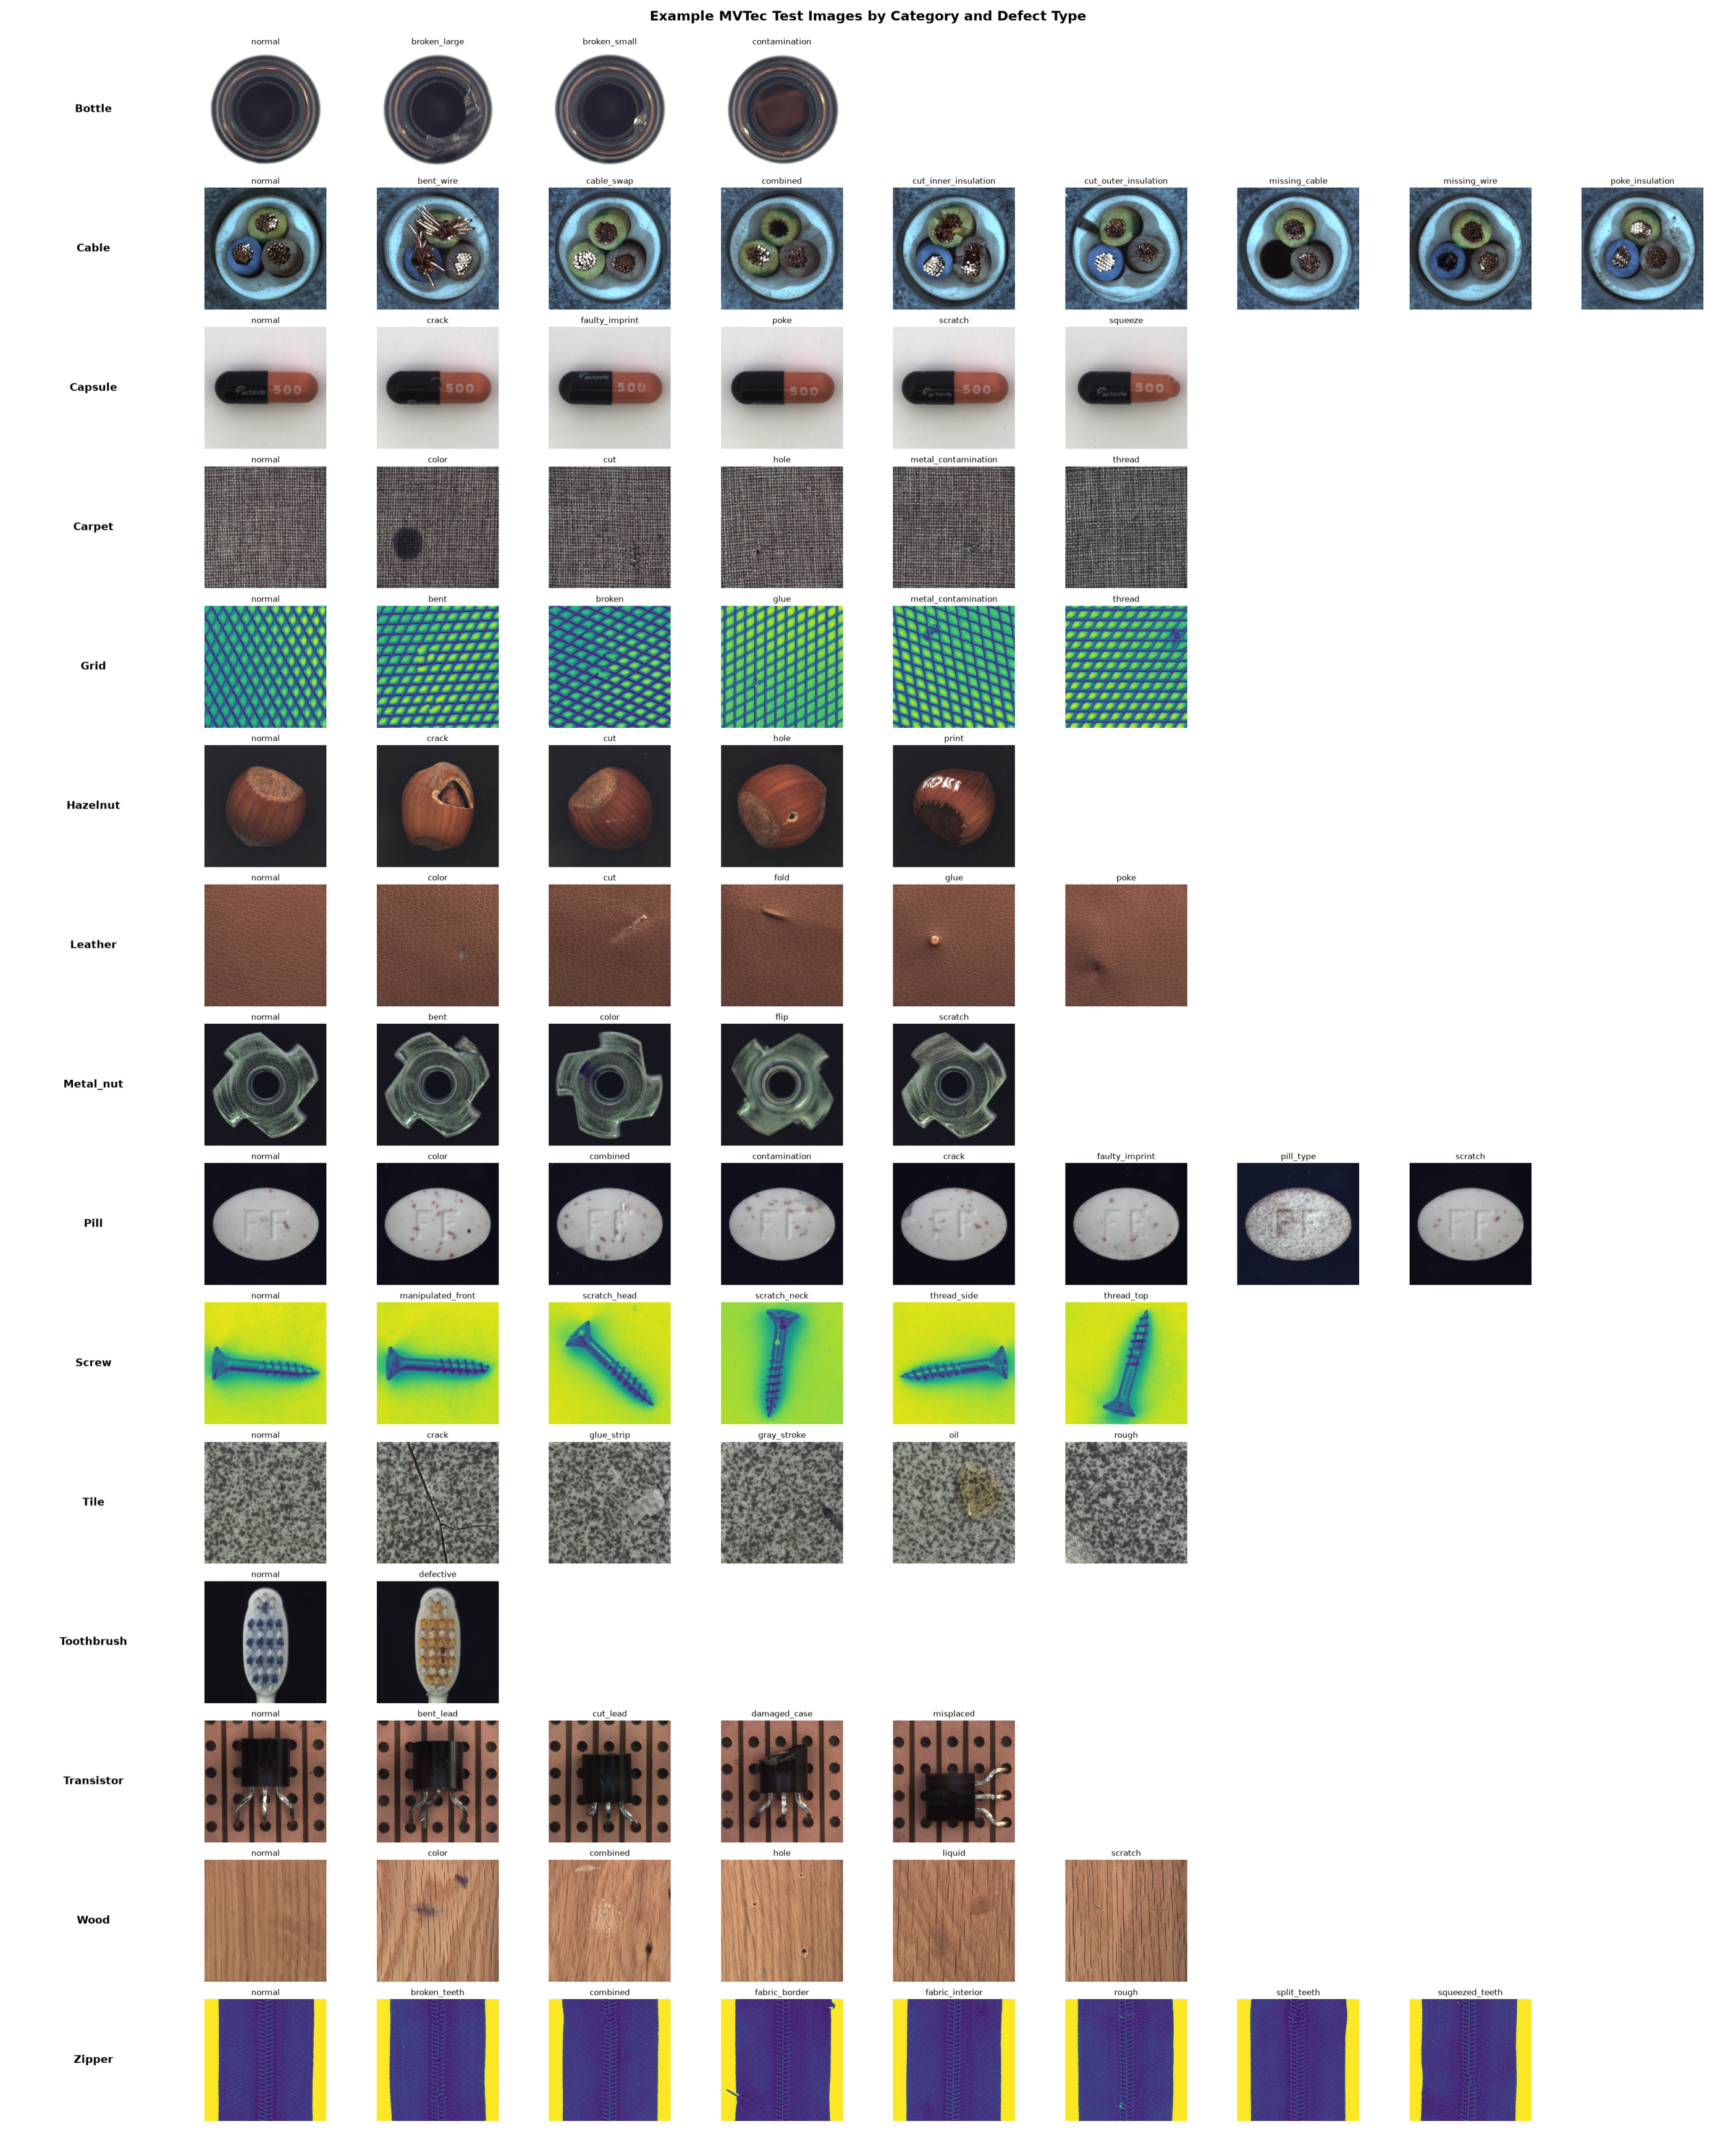

In [14]:
fig_path = IMAGE_DIR / "defect_examples.png"
seed = 42 # Set to none to generate random selection of samples

if fig_path.exists() and seed == 42:
    img = plt.imread(fig_path)

    plt.figure(figsize=(4 * max_types, 3 * len(categories)))
    plt.imshow(img)
    plt.axis("off")

else:
    fig, axes = plt.subplots(
        len(categories),
        max_types + 1,
        figsize=(4 * max_types, 3 * len(categories))
    )

    for row, cat in enumerate(categories):
        # Randomally sampel one image of each type for the current category from the test split
        sample: pd.DataFrame = (
            df[
                (df["category"] == cat)
                & (df["split"] == "test")
            ]
            .groupby("type", group_keys=False)
            .sample(n=1, random_state=seed)
        )

        # Makes it so good is always in the first column
        sample = sample.sort_values("type", key=lambda s: s.map(lambda x: (x != "good", x)))

        axes[row, 0].text(
        0.5,
        0.5,
        cat.capitalize(),
        fontsize=16,
        fontweight="bold",
        ha="center",
        va="center"
        )

        axes[row, 0].axis("off")

        for col, (_, record) in enumerate(sample.iterrows(), start=1):

            ax = axes[row, col]

            img = plt.imread(ROOT / record["path"])

            ax.imshow(img)
            ax.set_title(record["type"] if record["type"] != "good" else "normal")
            ax.axis("off")

        # hide unused columns
        for col in range(len(sample), max_types+1):
            axes[row, col].axis("off")

    fig.suptitle(
        "Example MVTec Test Images by Category and Defect Type",
        fontsize=20,
        fontweight="bold"
    )

    plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
    if seed == 42:
        plt.savefig(f'{IMAGE_DIR}/defect_examples.png', bbox_inches="tight", pad_inches=0.1)

plt.show()

## 4. Analyse image characteristics such as resolution, brightness, sharpness, and contrast.

This section investigates several image characteristics that may influence feature extraction and anomaly detection performance. Resolution, brightness, sharpness, and contrast are analysed to identify potential inconsistencies or preprocessing requirements.

Image-level statistics are computed for every image in the dataset. Brightness is measured as the mean pixel intensity, contrast as the standard deviation of pixel intensities, and sharpness using the variance of the Laplacian.

In [15]:
stats = []

stats_path = CACHE_DIR / "image_stats.csv"
if stats_path.exists():
    stats = pd.read_csv(stats_path)

else:
    for row in df.itertuples():

        img = cv2.imread(str(ROOT / row.path), cv2.IMREAD_GRAYSCALE)

        h, w = img.shape

        stats.append({
            "width": w,
            "height": h,
            "brightness": img.mean(), #0-255
            "sharpness": cv2.Laplacian(img, cv2.CV_64F).var(), #2nd derivative of how much pixels change around eachother
            "contrast": img.std(),
            "category": row.category
        })

    stats = pd.DataFrame(stats)
    stats.to_csv(stats_path, index=False)

stats

,width,height,brightness,sharpness,contrast,category
0,840,840,112.688258,45.320798,32.142516,tile
1,840,840,115.859580,56.040097,32.030617,tile
2,840,840,116.803467,42.640200,30.826356,tile
3,840,840,122.073248,44.382211,31.445054,tile
4,840,840,119.201998,43.464659,32.234905,tile
...,...,...,...,...,...,...
5349,1024,1024,101.904773,28.198043,35.883683,transistor
5350,1024,1024,81.684298,60.837512,42.768336,transistor
5351,1024,1024,83.817950,63.429646,42.665138,transistor
5352,1024,1024,81.310438,78.229432,40.392045,transistor


In [16]:
# Total statistics descriptions
print(stats[["width", "height"]].describe()) 
print("\n\nSize Value Counts:") 
print(stats[["width", "height"]].value_counts())

print("\n\nBrightness Description:") 
print(stats["brightness"].describe())

print("\n\nSharpness Description:")
print(stats["sharpness"].describe())

print("\n\nContrast Description:")
print(stats["contrast"].describe())

             width       height
count  5354.000000  5354.000000
mean    965.308181   965.308181
std     101.308699   101.308699
min     700.000000   700.000000
25%     900.000000   900.000000
50%    1024.000000  1024.000000
75%    1024.000000  1024.000000
max    1024.000000  1024.000000


Size Value Counts:
width  height
1024   1024      3595
800    800        434
1000   1000       351
840    840        347
700    700        335
900    900        292
Name: count, dtype: int64


Brightness Description:
count    5354.000000
mean      105.415137
std        40.431585
min        32.047122
25%        76.891354
50%       100.093348
75%       132.849590
max       199.836972
Name: brightness, dtype: float64


Sharpness Description:
count    5354.000000
mean       76.450210
std        81.861266
min        10.961572
25%        35.641264
50%        46.890881
75%        73.605106
max       499.997243
Name: sharpness, dtype: float64


Contrast Description:
count    5354.000000
mean       45.766358
s

In [17]:
summary_table = stats.groupby("category").agg({
    "brightness": ["mean", "std"],
    "sharpness": ["mean", "std"],
    "contrast": ["mean", "std"]
})

summary_table.columns = [
    f"{metric}_{stat}"
    for metric, stat in summary_table.columns
]

summary_table = summary_table.round(2).reset_index()

summary_table.to_csv(RESULTS_DIR / "dataset_stats.csv", index=False)
summary_table

,category,brightness_mean,brightness_std,sharpness_mean,sharpness_std,contrast_mean,contrast_std
0,bottle,136.74,1.71,44.38,4.63,92.72,0.95
1,cable,102.06,4.71,46.01,10.60,50.77,2.81
2,capsule,172.24,4.32,17.25,3.37,63.00,1.68
3,carpet,91.06,2.48,300.72,56.27,35.39,1.54
4,grid,114.11,9.23,30.09,11.40,39.18,7.52
5,hazelnut,51.72,4.13,43.01,3.84,26.49,5.13
6,leather,80.39,6.91,46.96,18.76,11.75,2.09
7,metal_nut,58.49,4.39,62.75,14.18,43.25,4.58
8,pill,76.33,4.96,142.10,96.86,78.45,4.05
9,screw,183.61,6.35,23.41,2.13,33.42,1.98


In [18]:
# Find how image sizes are distributed per category
print(
    stats.groupby("category")
    .agg({
        "width": ["mean", "std"],
        "height": ["mean", "std"],
    })
)

             width       height     
              mean  std    mean  std
category                            
bottle       900.0  0.0   900.0  0.0
cable       1024.0  0.0  1024.0  0.0
capsule     1000.0  0.0  1000.0  0.0
carpet      1024.0  0.0  1024.0  0.0
grid        1024.0  0.0  1024.0  0.0
hazelnut    1024.0  0.0  1024.0  0.0
leather     1024.0  0.0  1024.0  0.0
metal_nut    700.0  0.0   700.0  0.0
pill         800.0  0.0   800.0  0.0
screw       1024.0  0.0  1024.0  0.0
tile         840.0  0.0   840.0  0.0
toothbrush  1024.0  0.0  1024.0  0.0
transistor  1024.0  0.0  1024.0  0.0
wood        1024.0  0.0  1024.0  0.0
zipper      1024.0  0.0  1024.0  0.0


In [19]:
print(
    stats.groupby("category")
         .agg({
             "brightness": ["mean", "std", "min", "max"]
         })
)

print("\n\n",
    stats.groupby("category")
         .agg({
            "sharpness": ["mean", "std", "min", "max"]
         })
)

print("\n\n",
    stats.groupby("category")
         .agg({
            "contrast": ["mean", "std", "min", "max"]
         })
)     
            

            brightness                                  
                  mean       std         min         max
category                                                
bottle      136.736668  1.711485  133.190284  147.532817
cable       102.064252  4.713183   85.904635  113.301944
capsule     172.243125  4.317096  159.626214  190.269814
carpet       91.056939  2.484504   84.954001   98.572079
grid        114.109257  9.230085   95.737374  136.306748
hazelnut     51.721902  4.125551   37.764029   61.495345
leather      80.393443  6.913439   70.380040   95.773496
metal_nut    58.494415  4.393780   50.426035   69.751945
pill         76.325139  4.957171   67.485842   84.475886
screw       183.606749  6.351446  168.220042  199.836972
tile        116.352111  8.446481   96.259888  141.245376
toothbrush   47.017329  8.020109   32.047122   56.957409
transistor   79.515010  3.435621   71.608881  101.904773
wood        135.898267  7.197005  115.528628  157.483312
zipper      101.970293  2.01745

### Observations

Several notable observations can be made from the image characteristic analysis:

- Image resolution is consistent within each category but varies between categories, ranging from 700×700 to 1024×1024 pixels.
- Brightness varies significantly between categories due to differences in object appearance and material properties, but remains highly consistent within individual categories.
- Sharpness and contrast exhibit greater variation between categories, reflecting differences in texture complexity and surface structure.
- Categories such as carpet, wood, and toothbrush contain substantially more texture detail than smoother categories such as capsule and screw.

These findings suggest that resizing and normalization will be necessary during preprocessing, while category-specific texture complexity may influence anomaly detection performance.